# Tell me a story ... with Gapminder
This notebook is an example of a Gapminder story.  It looks at the implicit question posed by the graph at the bottom, where the life expectancy in Cambodia suddenly fell dramatically and answers the question: Why?

This notebook is here as an example for you to write your story about a country and variable from Gapminder of your choosing.  In addition, to the the variable you're explaining add another variable that gives a contrast.  Like here it could be the global average for that same variable or a continent-wide average or a comprable single country.  

We'll discuss in class how to submit these notebooks for HW 1.  Hopefully, we'll be using Github.

##  Load the Gapminder Dataset
We will load Jennifer Bryan's classic **Gapminder** dataset directly from the official GitHub repository using `pd.read_csv()`. Since the dataset is tab-separated, we set the delimiter parameter `sep='\t'`.

In [3]:
import pandas as pd

# Load the Gapminder dataset directly from GitHub to ensure Colab out-of-the-box compatibility
url = 'https://raw.githubusercontent.com/jennybc/gapminder/master/inst/extdata/gapminder.tsv'
df = pd.read_csv(url, sep='\t')

# Show the first 5 observations
display(df.head())
display(df['country'].unique())

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

### Global vs. Cambodia Life Expectancy over Time
Let's compare the global average life expectancy with that of Cambodia.

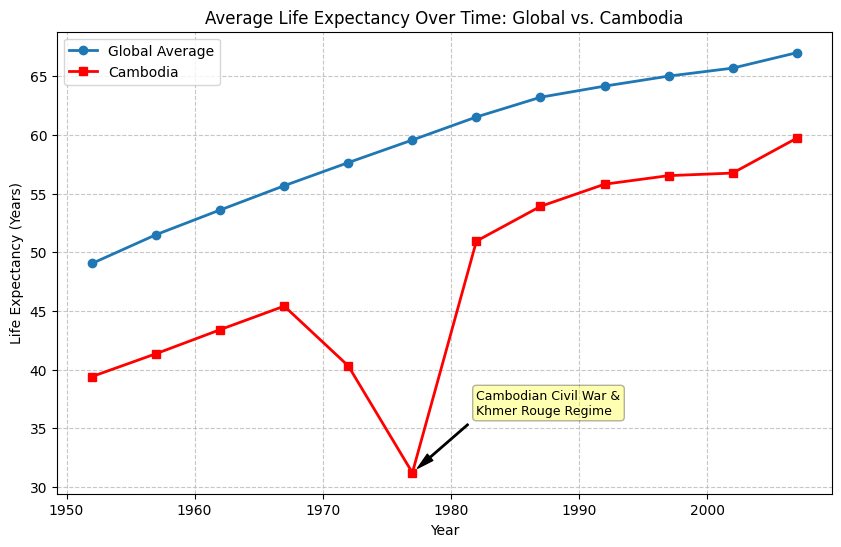

In [4]:
import matplotlib.pyplot as plt

# Calculate the global average life expectancy over time
global_yearly_life_expectancy = df.groupby('year')['lifeExp'].mean()

# Filter the dataset for Cambodia
cambodia_data = df[df['country'] == 'Cambodia'].set_index('year')['lifeExp']

plt.figure(figsize=(10, 6))
plt.plot(global_yearly_life_expectancy.index, global_yearly_life_expectancy.values, label='Global Average', marker='o', linewidth=2)
plt.plot(cambodia_data.index, cambodia_data.values, label='Cambodia', marker='s', linewidth=2, color='red')

# Find the coordinates for the lowest point on the Cambodia curve
min_year = cambodia_data.idxmin()
min_life_exp = cambodia_data.min()

# Add annotation above and to the right of the lowest point to avoid overlapping the x-axis
plt.annotate(
    'Cambodian Civil War &\nKhmer Rouge Regime',
    xy=(min_year, min_life_exp),
    xytext=(min_year + 5, min_life_exp + 5), # Positioned above and to the right
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontsize=9,
    color='black',
    bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3)
)

# Customizing the graph
plt.title('Average Life Expectancy Over Time: Global vs. Cambodia')
plt.ylabel('Life Expectancy (Years)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

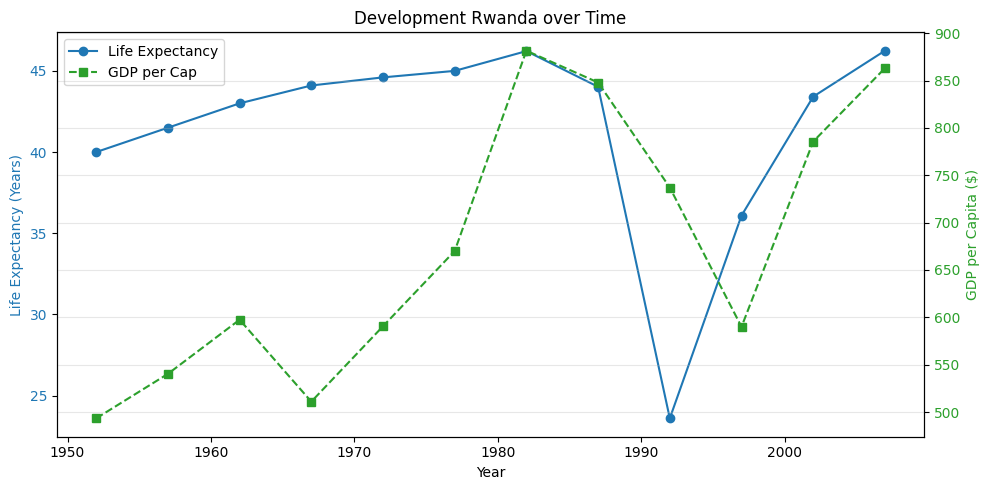

In [5]:
import matplotlib.pyplot as plt

country_data = df[df['country'] == 'Rwanda']

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Life Expectancy (Years)', color=color)
line1 = ax1.plot(country_data['year'], country_data['lifeExp'], color=color, marker='o', label='Life Expectancy')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('GDP per Capita ($)', color=color)
line2 = ax2.plot(country_data['year'], country_data['gdpPercap'], color=color, marker='s', linestyle='--', label='GDP per Cap')
ax2.tick_params(axis='y', labelcolor=color)



lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(f'Development Rwanda over Time')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

You can see a clear and sudden drop in the life expectancy of Rwanda. Similar to Cambodia there was politcal favoritism twards a local tribe from a foreign colonizer. A common tactic during the colonial age was to heavily favor the minority tribe. This gave the minorty group power and they excepted the foreign nation's rule. This also made them into an enemy of the other tribes in the area. This leads the minority power reliant on the foreign nation for defense against and uprise so it keeps the colonizer in control and allows them to hold control while suppling just enough support to this minority power to keep them in rule. This is a far more cost effective method of colonizing. The only problem is when the colonizer leaves the minority power is introuble. So thats what happend the colonizers left and later on a civil war broke out and led to genocides and choas plumiting the life expectancy and GDP for years. It took them over 20 years to fully recover from all the conflict.